# Netflix Data Analysis

## Objective

The objective of this project is to analyze Netflix's content library and identify trends in movies, TV shows, genres, countries, and content growth over time.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#   Load Dataset

In [20]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Understanding the Dataset

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### Observation

The dataset contains information about Netflix Movies and TV Shows including title, country, director, release year, and genres.

## Data Cleaning


In [22]:
df.isnull().sum()
df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

df.drop_duplicates(inplace=True)

### Observation

Missing values were handled and duplicate records were removed to improve data quality.


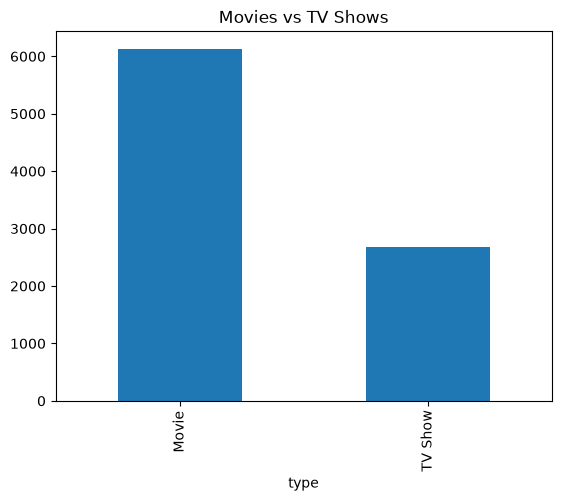

In [23]:
df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows")
plt.show()

### Insight

Movies significantly outnumber TV Shows on Netflix.

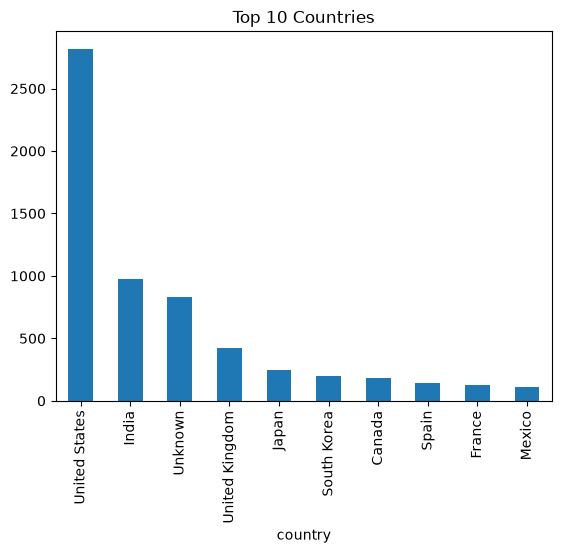

In [24]:
country_counts = df["country"].value_counts().head(10)

country_counts.plot(kind="bar")

plt.title("Top 10 Countries")
plt.show()

### Insight

The United States contributes the largest amount of Netflix content.

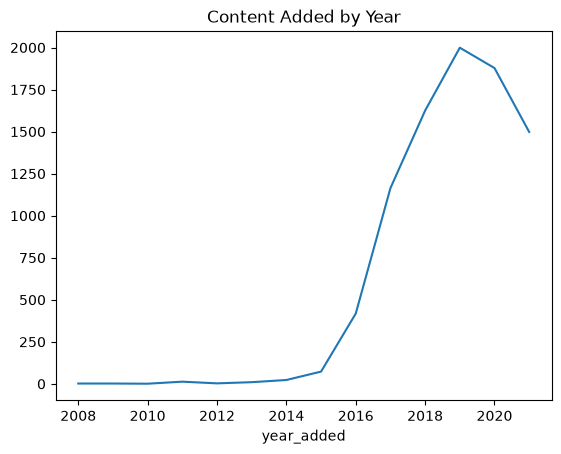

In [25]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

df["year_added"].value_counts().sort_index().plot()

plt.title("Content Added by Year")

plt.show()

### Insight

Netflix experienced rapid content growth after 2015.

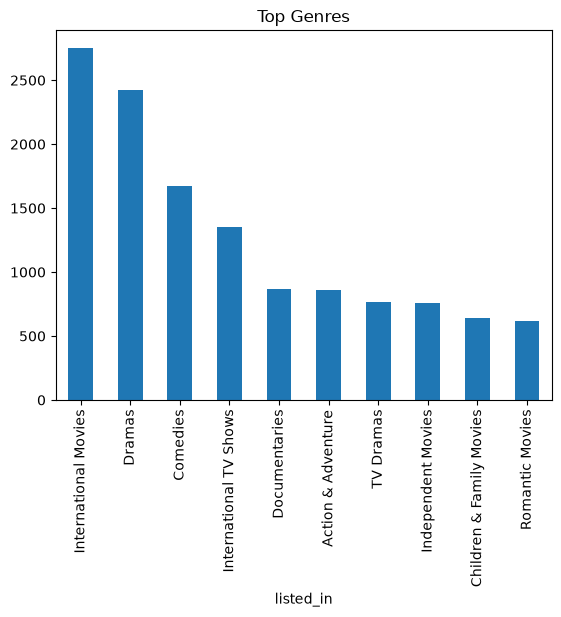

In [26]:
genres = df["listed_in"].str.split(", ").explode()

genres.value_counts().head(10).plot(kind="bar")

plt.title("Top Genres")

plt.show()

### Insight

Drama and International Movies are among the most common genres on Netflix.

# Conclusion

1. Netflix contains more Movies than TV Shows.
2. The United States produces the highest amount of content.
3. Content additions increased rapidly after 2015.
4. Drama is one of the dominant genres.
5. Netflix expanded aggressively between 2016 and 2020.